# **Case Study - London Housing**

## **1. Sourcing and Loading**

### 1.1 Importing Libraries

In [52]:
# Import the pandas, numpy libraries as pd, and np respectively.
import pandas as pd
import numpy as np

# Load the pyplot collection of functions from matplotlib, as plt 
import matplotlib.pyplot as plt 

### 1.2. Loading the data

In [53]:
# Note:
# The original London Datastore URL now returns HTTP 403 (Forbidden)
# when accessed programmatically. The same dataset was downloaded
# manually from the official London Datastore and read locally.



#url_LondonHousePrices =  "/Users/peiyeewhetsel/Desktop/UK_House_price_index.xlsx"
url_LondonHousePrices =  "/Users/peiyeewhetsel/Documents/GitHub/DataScienceTrack/mini-projects/LondonHousePrices/UK_House_price_index.xlsx"

properties = pd.read_excel(
    url_LondonHousePrices,
    sheet_name="Average price"
)


## **2. Cleaning, transforming, and visualizing**

### 2.1. Exploring data

In [54]:
# Use .shape feature of pandas DataFrames to look at the number of rows and columns.
properties.shape

(377, 49)

In [55]:
# Display column types and missing values
properties.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 377 entries, 0 to 376
Data columns (total 49 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   Unnamed: 0            376 non-null    datetime64[ns]
 1   City of London        377 non-null    object        
 2   Barking & Dagenham    377 non-null    object        
 3   Barnet                377 non-null    object        
 4   Bexley                377 non-null    object        
 5   Brent                 377 non-null    object        
 6   Bromley               377 non-null    object        
 7   Camden                377 non-null    object        
 8   Croydon               377 non-null    object        
 9   Ealing                377 non-null    object        
 10  Enfield               377 non-null    object        
 11  Greenwich             377 non-null    object        
 12  Hackney               377 non-null    object        
 13  Hammersmith & Fulham

In [56]:
# View the first 5 rows
properties.head()

,Unnamed: 0,City of London,Barking & Dagenham,Barnet,Bexley,Brent,Bromley,Camden,Croydon,Ealing,...,NORTH WEST,YORKS & THE HUMBER,EAST MIDLANDS,WEST MIDLANDS,EAST OF ENGLAND,LONDON,SOUTH EAST,SOUTH WEST,Unnamed: 47,England
0,NaT,E09000001,E09000002,E09000003,E09000004,E09000005,E09000006,E09000007,E09000008,E09000009,...,E12000002,E12000003,E12000004,E12000005,E12000006,E12000007,E12000008,E12000009,NaN,E92000001
1,1995-01-01,90347,51870,98948,64956,76880,83082,119775,70118,85469,...,40907,42171,43856,46470,56098,79687,64502,52799,NaN,50231
2,1995-02-01,81213,52513,98848,64786,77651,83068,118365,69908,86551,...,40877,41912,44344,47249,55991,77913,64196,52462,NaN,50130
3,1995-03-01,78168,52701,97848,64366,77644,82856,119131,69666,87067,...,41351,42544,43701,47345,55574,79110,64597,51716,NaN,50229
4,1995-04-01,76172,54618,96273,64276,78668,82525,118948,69562,87933,...,41195,42934,44414,47359,55966,79708,65111,52877,NaN,50597


### 2.2. Cleaning the data (part 1)

In [57]:
# Assign the transposed version of the original to a new variable
properties_T = properties.T

In [58]:
# Check the head of the new Transposed DataFrame
properties_T.head()

,0,1,2,3,4,5,6,7,8,9,...,367,368,369,370,371,372,373,374,375,376
Unnamed: 0,NaT,1995-01-01 00:00:00,1995-02-01 00:00:00,1995-03-01 00:00:00,1995-04-01 00:00:00,1995-05-01 00:00:00,1995-06-01 00:00:00,1995-07-01 00:00:00,1995-08-01 00:00:00,1995-09-01 00:00:00,...,2025-07-01 00:00:00,2025-08-01 00:00:00,2025-09-01 00:00:00,2025-10-01 00:00:00,2025-11-01 00:00:00,2025-12-01 00:00:00,2026-01-01 00:00:00,2026-02-01 00:00:00,2026-03-01 00:00:00,2026-04-01 00:00:00
City of London,E09000001,90347,81213,78168,76172,83392,93757,108801,110976,103215,...,863687,852425,765344,731418,709478,762272,732377,691441,604656,612427
Barking & Dagenham,E09000002,51870,52513,52701,54618,54524,55200,53569,53691,52909,...,358532,354988,357277,359638,361107,357921,358499,361952,360125,360007
Barnet,E09000003,98948,98848,97848,96273,95737,95577,96992,97968,98936,...,630591,623157,614607,597772,595567,590558,585156,585233,587001,587297
Bexley,E09000004,64956,64786,64366,64276,63995,64251,63721,64431,64508,...,405681,407407,410713,413619,416894,413487,411474,404957,408880,408488


In [59]:
# To confirm what the row indices are, call the .index variable on the properties DataFrame
properties_T.index

Index(['Unnamed: 0', 'City of London', 'Barking & Dagenham', 'Barnet',
       'Bexley', 'Brent', 'Bromley', 'Camden', 'Croydon', 'Ealing', 'Enfield',
       'Greenwich', 'Hackney', 'Hammersmith & Fulham', 'Haringey', 'Harrow',
       'Havering', 'Hillingdon', 'Hounslow', 'Islington',
       'Kensington & Chelsea', 'Kingston upon Thames', 'Lambeth', 'Lewisham',
       'Merton', 'Newham', 'Redbridge', 'Richmond upon Thames', 'Southwark',
       'Sutton', 'Tower Hamlets', 'Waltham Forest', 'Wandsworth',
       'Westminster', 'Unnamed: 34', 'Inner London', 'Outer London',
       'Unnamed: 37', 'NORTH EAST', 'NORTH WEST', 'YORKS & THE HUMBER',
       'EAST MIDLANDS', 'WEST MIDLANDS', 'EAST OF ENGLAND', 'LONDON',
       'SOUTH EAST', 'SOUTH WEST', 'Unnamed: 47', 'England'],
      dtype='object')

In [60]:
# Call the .reset_index() method to reset the indices, and the reassign the result to properties
properties_T = properties_T.reset_index()

In [61]:
#check out our DataFrames indices: 
properties_T.index

RangeIndex(start=0, stop=49, step=1)

In [62]:
# Call the head() function again on properties_T to check out the new row indices: 
properties_T.head()

,index,0,1,2,3,4,5,6,7,8,...,367,368,369,370,371,372,373,374,375,376
0,Unnamed: 0,NaT,1995-01-01 00:00:00,1995-02-01 00:00:00,1995-03-01 00:00:00,1995-04-01 00:00:00,1995-05-01 00:00:00,1995-06-01 00:00:00,1995-07-01 00:00:00,1995-08-01 00:00:00,...,2025-07-01 00:00:00,2025-08-01 00:00:00,2025-09-01 00:00:00,2025-10-01 00:00:00,2025-11-01 00:00:00,2025-12-01 00:00:00,2026-01-01 00:00:00,2026-02-01 00:00:00,2026-03-01 00:00:00,2026-04-01 00:00:00
1,City of London,E09000001,90347,81213,78168,76172,83392,93757,108801,110976,...,863687,852425,765344,731418,709478,762272,732377,691441,604656,612427
2,Barking & Dagenham,E09000002,51870,52513,52701,54618,54524,55200,53569,53691,...,358532,354988,357277,359638,361107,357921,358499,361952,360125,360007
3,Barnet,E09000003,98948,98848,97848,96273,95737,95577,96992,97968,...,630591,623157,614607,597772,595567,590558,585156,585233,587001,587297
4,Bexley,E09000004,64956,64786,64366,64276,63995,64251,63721,64431,...,405681,407407,410713,413619,416894,413487,411474,404957,408880,408488


In [63]:
# To confirm that the DataFrame's columns are mainly just integers, call the .columns feature on the DataFrame:
properties_T.columns

Index(['index',       0,       1,       2,       3,       4,       5,       6,
             7,       8,
       ...
           367,     368,     369,     370,     371,     372,     373,     374,
           375,     376],
      dtype='object', length=378)

In [64]:
# Call the iloc[] method with double square brackets on the properties_T DataFrame, to see the row at index 0.
properties_T.iloc[[0]]

,index,0,1,2,3,4,5,6,7,8,...,367,368,369,370,371,372,373,374,375,376
0,Unnamed: 0,NaT,1995-01-01 00:00:00,1995-02-01 00:00:00,1995-03-01 00:00:00,1995-04-01 00:00:00,1995-05-01 00:00:00,1995-06-01 00:00:00,1995-07-01 00:00:00,1995-08-01 00:00:00,...,2025-07-01 00:00:00,2025-08-01 00:00:00,2025-09-01 00:00:00,2025-10-01 00:00:00,2025-11-01 00:00:00,2025-12-01 00:00:00,2026-01-01 00:00:00,2026-02-01 00:00:00,2026-03-01 00:00:00,2026-04-01 00:00:00


In [65]:
#reassign the columns of your DataFrame the values within this row at index 0 by making use of the *.columns* feature.
properties_T.columns = properties_T.iloc[0]

# Check out the DataFrame again: 
properties_T.head()

,Unnamed: 0,NaT,1995-01-01 00:00:00,1995-02-01 00:00:00,1995-03-01 00:00:00,1995-04-01 00:00:00,1995-05-01 00:00:00,1995-06-01 00:00:00,1995-07-01 00:00:00,1995-08-01 00:00:00,...,2025-07-01 00:00:00,2025-08-01 00:00:00,2025-09-01 00:00:00,2025-10-01 00:00:00,2025-11-01 00:00:00,2025-12-01 00:00:00,2026-01-01 00:00:00,2026-02-01 00:00:00,2026-03-01 00:00:00,2026-04-01 00:00:00
0,Unnamed: 0,NaT,1995-01-01 00:00:00,1995-02-01 00:00:00,1995-03-01 00:00:00,1995-04-01 00:00:00,1995-05-01 00:00:00,1995-06-01 00:00:00,1995-07-01 00:00:00,1995-08-01 00:00:00,...,2025-07-01 00:00:00,2025-08-01 00:00:00,2025-09-01 00:00:00,2025-10-01 00:00:00,2025-11-01 00:00:00,2025-12-01 00:00:00,2026-01-01 00:00:00,2026-02-01 00:00:00,2026-03-01 00:00:00,2026-04-01 00:00:00
1,City of London,E09000001,90347,81213,78168,76172,83392,93757,108801,110976,...,863687,852425,765344,731418,709478,762272,732377,691441,604656,612427
2,Barking & Dagenham,E09000002,51870,52513,52701,54618,54524,55200,53569,53691,...,358532,354988,357277,359638,361107,357921,358499,361952,360125,360007
3,Barnet,E09000003,98948,98848,97848,96273,95737,95577,96992,97968,...,630591,623157,614607,597772,595567,590558,585156,585233,587001,587297
4,Bexley,E09000004,64956,64786,64366,64276,63995,64251,63721,64431,...,405681,407407,410713,413619,416894,413487,411474,404957,408880,408488


In [66]:
# Use drop() method to drop the row at index 0.
properties_T = properties_T.drop(0)

In [67]:
# Now check out the DataFrame again to see how it looks. 
properties_T.head()

,Unnamed: 0,NaT,1995-01-01 00:00:00,1995-02-01 00:00:00,1995-03-01 00:00:00,1995-04-01 00:00:00,1995-05-01 00:00:00,1995-06-01 00:00:00,1995-07-01 00:00:00,1995-08-01 00:00:00,...,2025-07-01 00:00:00,2025-08-01 00:00:00,2025-09-01 00:00:00,2025-10-01 00:00:00,2025-11-01 00:00:00,2025-12-01 00:00:00,2026-01-01 00:00:00,2026-02-01 00:00:00,2026-03-01 00:00:00,2026-04-01 00:00:00
1,City of London,E09000001,90347,81213,78168,76172,83392,93757,108801,110976,...,863687,852425,765344,731418,709478,762272,732377,691441,604656,612427
2,Barking & Dagenham,E09000002,51870,52513,52701,54618,54524,55200,53569,53691,...,358532,354988,357277,359638,361107,357921,358499,361952,360125,360007
3,Barnet,E09000003,98948,98848,97848,96273,95737,95577,96992,97968,...,630591,623157,614607,597772,595567,590558,585156,585233,587001,587297
4,Bexley,E09000004,64956,64786,64366,64276,63995,64251,63721,64431,...,405681,407407,410713,413619,416894,413487,411474,404957,408880,408488
5,Brent,E09000005,76880,77651,77644,78668,79464,80118,79920,79295,...,558272,555794,556967,557828,567067,568445,553470,537567,543165,547995


### 2.3. Cleaning the data (part 2)

In [68]:
# Rename 'Unnamed: 0' to 'London Borough' and 'NaN' to 'ID'.
properties_T = properties_T.rename(columns = {'Unnamed: 0':'London_Borough', pd.NaT: 'ID'})

# Verify the DataFrame
properties_T.head()

,London_Borough,ID,1995-01-01 00:00:00,1995-02-01 00:00:00,1995-03-01 00:00:00,1995-04-01 00:00:00,1995-05-01 00:00:00,1995-06-01 00:00:00,1995-07-01 00:00:00,1995-08-01 00:00:00,...,2025-07-01 00:00:00,2025-08-01 00:00:00,2025-09-01 00:00:00,2025-10-01 00:00:00,2025-11-01 00:00:00,2025-12-01 00:00:00,2026-01-01 00:00:00,2026-02-01 00:00:00,2026-03-01 00:00:00,2026-04-01 00:00:00
1,City of London,E09000001,90347,81213,78168,76172,83392,93757,108801,110976,...,863687,852425,765344,731418,709478,762272,732377,691441,604656,612427
2,Barking & Dagenham,E09000002,51870,52513,52701,54618,54524,55200,53569,53691,...,358532,354988,357277,359638,361107,357921,358499,361952,360125,360007
3,Barnet,E09000003,98948,98848,97848,96273,95737,95577,96992,97968,...,630591,623157,614607,597772,595567,590558,585156,585233,587001,587297
4,Bexley,E09000004,64956,64786,64366,64276,63995,64251,63721,64431,...,405681,407407,410713,413619,416894,413487,411474,404957,408880,408488
5,Brent,E09000005,76880,77651,77644,78668,79464,80118,79920,79295,...,558272,555794,556967,557828,567067,568445,553470,537567,543165,547995


In [69]:
# Get the number of columns on the DataFrame.
properties_T.columns

Index([   'London_Borough',                'ID', 1995-01-01 00:00:00,
       1995-02-01 00:00:00, 1995-03-01 00:00:00, 1995-04-01 00:00:00,
       1995-05-01 00:00:00, 1995-06-01 00:00:00, 1995-07-01 00:00:00,
       1995-08-01 00:00:00,
       ...
       2025-07-01 00:00:00, 2025-08-01 00:00:00, 2025-09-01 00:00:00,
       2025-10-01 00:00:00, 2025-11-01 00:00:00, 2025-12-01 00:00:00,
       2026-01-01 00:00:00, 2026-02-01 00:00:00, 2026-03-01 00:00:00,
       2026-04-01 00:00:00],
      dtype='object', name=0, length=378)

### 2.4. Transforming the data

In [70]:
# Transforms many columns into two columns: One column for the column names, and one column for the values.
# Keep the columns 'London_Borough', and 'ID' exactly as they are.
clean_properties = pd.melt(properties_T, id_vars= ['London_Borough', 'ID'])

# Check the new DataFrame again.
clean_properties.head()

,London_Borough,ID,0,value
0,City of London,E09000001,1995-01-01 00:00:00,90347
1,Barking & Dagenham,E09000002,1995-01-01 00:00:00,51870
2,Barnet,E09000003,1995-01-01 00:00:00,98948
3,Bexley,E09000004,1995-01-01 00:00:00,64956
4,Brent,E09000005,1995-01-01 00:00:00,76880


In [71]:
# Re-name the column names
clean_properties = clean_properties.rename(columns = {0: 'Month', 'value': 'Average_price'})

# Check out the DataFrame: 
clean_properties.head()

,London_Borough,ID,Month,Average_price
0,City of London,E09000001,1995-01-01 00:00:00,90347
1,Barking & Dagenham,E09000002,1995-01-01 00:00:00,51870
2,Barnet,E09000003,1995-01-01 00:00:00,98948
3,Bexley,E09000004,1995-01-01 00:00:00,64956
4,Brent,E09000005,1995-01-01 00:00:00,76880


In [72]:
# Use the .dtypes attribute to check the data types of our clean_properties DataFrame:
clean_properties.dtypes

London_Borough    object
ID                object
Month             object
Average_price     object
dtype: object

In [73]:
# Check if there are any missing values on the DataFrame:
clean_properties.count()

London_Borough    18048
ID                16920
Month             18048
Average_price     16920
dtype: int64

### 2.5. Cleaning the data (part 3)

In [74]:
# Check out the unique values of the 'London_Borough' column to see if they're all there.
clean_properties['London_Borough'].unique()

array(['City of London', 'Barking & Dagenham', 'Barnet', 'Bexley',
       'Brent', 'Bromley', 'Camden', 'Croydon', 'Ealing', 'Enfield',
       'Greenwich', 'Hackney', 'Hammersmith & Fulham', 'Haringey',
       'Harrow', 'Havering', 'Hillingdon', 'Hounslow', 'Islington',
       'Kensington & Chelsea', 'Kingston upon Thames', 'Lambeth',
       'Lewisham', 'Merton', 'Newham', 'Redbridge',
       'Richmond upon Thames', 'Southwark', 'Sutton', 'Tower Hamlets',
       'Waltham Forest', 'Wandsworth', 'Westminster', 'Unnamed: 34',
       'Inner London', 'Outer London', 'Unnamed: 37', 'NORTH EAST',
       'NORTH WEST', 'YORKS & THE HUMBER', 'EAST MIDLANDS',
       'WEST MIDLANDS', 'EAST OF ENGLAND', 'LONDON', 'SOUTH EAST',
       'SOUTH WEST', 'Unnamed: 47', 'England'], dtype=object)

In [75]:
# Subset clean_properties on the condition: df['London_Borough'] == 'Unnamed: 34' to see what information these rows contain. 
clean_properties[clean_properties['London_Borough'].str.contains('Unnamed:')]
#clean_properties[clean_properties['London_Borough'] == ''].head()

,London_Borough,ID,Month,Average_price
33,Unnamed: 34,NaN,1995-01-01 00:00:00,NaN
36,Unnamed: 37,NaN,1995-01-01 00:00:00,NaN
46,Unnamed: 47,NaN,1995-01-01 00:00:00,NaN
81,Unnamed: 34,NaN,1995-02-01 00:00:00,NaN
84,Unnamed: 37,NaN,1995-02-01 00:00:00,NaN
...,...,...,...,...
17988,Unnamed: 37,NaN,2026-03-01 00:00:00,NaN
17998,Unnamed: 47,NaN,2026-03-01 00:00:00,NaN
18033,Unnamed: 34,NaN,2026-04-01 00:00:00,NaN
18036,Unnamed: 37,NaN,2026-04-01 00:00:00,NaN


In [76]:
# Do the same for 'Unnamed: 37' and 'Unnamed: 47'
clean_properties[clean_properties['London_Borough'].isin(['Unnamed: 37', 'Unnamed: 47'])].head()

,London_Borough,ID,Month,Average_price
36,Unnamed: 37,NaN,1995-01-01 00:00:00,NaN
46,Unnamed: 47,NaN,1995-01-01 00:00:00,NaN
84,Unnamed: 37,NaN,1995-02-01 00:00:00,NaN
94,Unnamed: 47,NaN,1995-02-01 00:00:00,NaN
132,Unnamed: 37,NaN,1995-03-01 00:00:00,NaN


In [77]:
# Check how many rows have NAs as their value for ID. 
clean_properties[clean_properties['ID'].isna()]

,London_Borough,ID,Month,Average_price
33,Unnamed: 34,NaN,1995-01-01 00:00:00,NaN
36,Unnamed: 37,NaN,1995-01-01 00:00:00,NaN
46,Unnamed: 47,NaN,1995-01-01 00:00:00,NaN
81,Unnamed: 34,NaN,1995-02-01 00:00:00,NaN
84,Unnamed: 37,NaN,1995-02-01 00:00:00,NaN
...,...,...,...,...
17988,Unnamed: 37,NaN,2026-03-01 00:00:00,NaN
17998,Unnamed: 47,NaN,2026-03-01 00:00:00,NaN
18033,Unnamed: 34,NaN,2026-04-01 00:00:00,NaN
18036,Unnamed: 37,NaN,2026-04-01 00:00:00,NaN


In [78]:
# Make a new variable 'NaNFreeDF1' and assign it the result of filtering clean_properties
NaNFreeDF1 = clean_properties[clean_properties['Average_price'].notna()]
NaNFreeDF1.head(48)

,London_Borough,ID,Month,Average_price
0,City of London,E09000001,1995-01-01 00:00:00,90347
1,Barking & Dagenham,E09000002,1995-01-01 00:00:00,51870
2,Barnet,E09000003,1995-01-01 00:00:00,98948
3,Bexley,E09000004,1995-01-01 00:00:00,64956
4,Brent,E09000005,1995-01-01 00:00:00,76880
5,Bromley,E09000006,1995-01-01 00:00:00,83082
6,Camden,E09000007,1995-01-01 00:00:00,119775
7,Croydon,E09000008,1995-01-01 00:00:00,70118
8,Ealing,E09000009,1995-01-01 00:00:00,85469
9,Enfield,E09000010,1995-01-01 00:00:00,77018


In [79]:
# Count the nunber of rows in the new DataFrame
NaNFreeDF1.count()

London_Borough    16920
ID                16920
Month             16920
Average_price     16920
dtype: int64

In [80]:
# filtering the data with NaN values
NaNFreeDF2 = clean_properties.dropna()
NaNFreeDF2.head(48)

,London_Borough,ID,Month,Average_price
0,City of London,E09000001,1995-01-01 00:00:00,90347
1,Barking & Dagenham,E09000002,1995-01-01 00:00:00,51870
2,Barnet,E09000003,1995-01-01 00:00:00,98948
3,Bexley,E09000004,1995-01-01 00:00:00,64956
4,Brent,E09000005,1995-01-01 00:00:00,76880
5,Bromley,E09000006,1995-01-01 00:00:00,83082
6,Camden,E09000007,1995-01-01 00:00:00,119775
7,Croydon,E09000008,1995-01-01 00:00:00,70118
8,Ealing,E09000009,1995-01-01 00:00:00,85469
9,Enfield,E09000010,1995-01-01 00:00:00,77018


In [81]:
# Do a count on this DataFrame object: 
NaNFreeDF2.count()

London_Borough    16920
ID                16920
Month             16920
Average_price     16920
dtype: int64

In [82]:
NaNFreeDF2['London_Borough'].unique()

array(['City of London', 'Barking & Dagenham', 'Barnet', 'Bexley',
       'Brent', 'Bromley', 'Camden', 'Croydon', 'Ealing', 'Enfield',
       'Greenwich', 'Hackney', 'Hammersmith & Fulham', 'Haringey',
       'Harrow', 'Havering', 'Hillingdon', 'Hounslow', 'Islington',
       'Kensington & Chelsea', 'Kingston upon Thames', 'Lambeth',
       'Lewisham', 'Merton', 'Newham', 'Redbridge',
       'Richmond upon Thames', 'Southwark', 'Sutton', 'Tower Hamlets',
       'Waltham Forest', 'Wandsworth', 'Westminster', 'Inner London',
       'Outer London', 'NORTH EAST', 'NORTH WEST', 'YORKS & THE HUMBER',
       'EAST MIDLANDS', 'WEST MIDLANDS', 'EAST OF ENGLAND', 'LONDON',
       'SOUTH EAST', 'SOUTH WEST', 'England'], dtype=object)

In [83]:
# Using the .shape attribute, compare the dimensions of clean_properties, NaNFreeDF1, and NaNFreeDF2:
print(clean_properties.shape)
print(NaNFreeDF1.shape)
print(NaNFreeDF2.shape)

(18048, 4)
(16920, 4)
(16920, 4)


In [84]:
# Make a list of non-boroughs. 
nonBoroughs = ['Inner London', 'Outer London', 
               'NORTH EAST', 'NORTH WEST', 'YORKS & THE HUMBER', 
               'EAST MIDLANDS', 'WEST MIDLANDS',
              'EAST OF ENGLAND', 'LONDON', 'SOUTH EAST', 
              'SOUTH WEST', 'England']

# Filter NanFreeDF2 first on the condition that the rows' values for London_Borough is in the nonBoroughs list. 
NaNFreeDF2[NaNFreeDF2.London_Borough.isin(nonBoroughs)]

,London_Borough,ID,Month,Average_price
34,Inner London,E13000001,1995-01-01 00:00:00,85892
35,Outer London,E13000002,1995-01-01 00:00:00,76196
37,NORTH EAST,E12000001,1995-01-01 00:00:00,39809
38,NORTH WEST,E12000002,1995-01-01 00:00:00,40907
39,YORKS & THE HUMBER,E12000003,1995-01-01 00:00:00,42171
...,...,...,...,...
18042,EAST OF ENGLAND,E12000006,2026-04-01 00:00:00,336300
18043,LONDON,E12000007,2026-04-01 00:00:00,552655
18044,SOUTH EAST,E12000008,2026-04-01 00:00:00,376819
18045,SOUTH WEST,E12000009,2026-04-01 00:00:00,302618


In [85]:
# The non-borough rows are excluded
NaNFreeDF2 = NaNFreeDF2[~NaNFreeDF2.London_Borough.isin(nonBoroughs)]

# Check the DataFrame.
NaNFreeDF2.head()

,London_Borough,ID,Month,Average_price
0,City of London,E09000001,1995-01-01 00:00:00,90347
1,Barking & Dagenham,E09000002,1995-01-01 00:00:00,51870
2,Barnet,E09000003,1995-01-01 00:00:00,98948
3,Bexley,E09000004,1995-01-01 00:00:00,64956
4,Brent,E09000005,1995-01-01 00:00:00,76880


In [86]:
# Make a new variable called 'df' as the final, analysis-ready DataFrame
df = NaNFreeDF2

df.head()

,London_Borough,ID,Month,Average_price
0,City of London,E09000001,1995-01-01 00:00:00,90347
1,Barking & Dagenham,E09000002,1995-01-01 00:00:00,51870
2,Barnet,E09000003,1995-01-01 00:00:00,98948
3,Bexley,E09000004,1995-01-01 00:00:00,64956
4,Brent,E09000005,1995-01-01 00:00:00,76880


In [87]:
df.dtypes

London_Borough    object
ID                object
Month             object
Average_price     object
dtype: object

In [88]:
# Convert Average_price from text to numeric
df['Average_price'] = pd.to_numeric(df['Average_price'])

### 2.6. Visualizing the data

/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/pandas/core/indexes/base.py:7654: FutureWarning: Dtype inference on a pandas object (Series, Index, ExtensionArray) is deprecated. The Index constructor will keep the original dtype in the future. Call `infer_objects` on the result to get the old behavior.
  return Index(sequences[0], name=names)


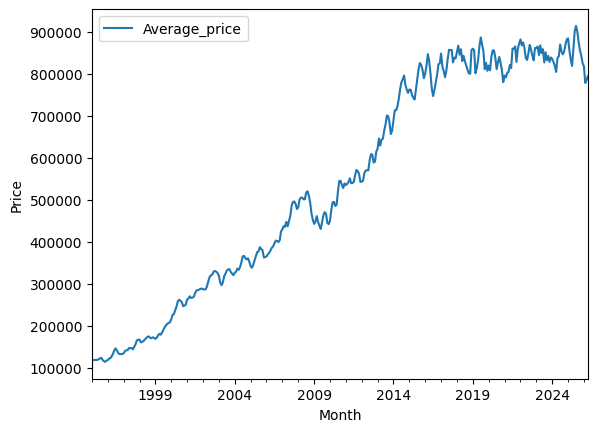

In [89]:
# First of all, make a variable called camden_prices, and assign it the result of filtering df on the following condition:
# df['London_Borough'] == 'Camden'
camden_prices = df[df['London_Borough'] == 'Camden']

# Make a variable called ax. Assign it the result of calling the plot() method, and plugging in the following values as parameters:
ax = camden_prices.plot(kind = 'line', x = 'Month', y = 'Average_price')

# Finally, call the set_ylabel() method on ax, and set that label to the string: 'Price'. 
ax.set_ylabel('Price')
plt.show()

In [90]:
# Extract the year from each date in the Month column and save it as a new Year column.
df['Year'] = df['Month'].apply(lambda x: x.year)

# Call the tail() method on df
df.tail()

,London_Borough,ID,Month,Average_price,Year
18028,Sutton,E09000029,2026-04-01 00:00:00,452352,2026
18029,Tower Hamlets,E09000030,2026-04-01 00:00:00,457504,2026
18030,Waltham Forest,E09000031,2026-04-01 00:00:00,524099,2026
18031,Wandsworth,E09000032,2026-04-01 00:00:00,670960,2026
18032,Westminster,E09000033,2026-04-01 00:00:00,814679,2026


In [91]:
# Group the data by London_Borough and Year, then calculate the mean house price for each group.
dfg = df.groupby(by=['London_Borough', 'Year']).mean(numeric_only=True)
dfg.columns
dfg.sample(10)

,,Average_price
London_Borough,Year,
Kensington & Chelsea,2020,1.428848e+06
Camden,2018,8.341242e+05
Greenwich,2017,4.136602e+05
Enfield,2019,4.168105e+05
Camden,1999,1.892612e+05
Harrow,2020,4.659638e+05
Barking & Dagenham,2023,3.469553e+05
Hammersmith & Fulham,2007,4.910726e+05
Enfield,2004,2.186318e+05


In [92]:
# Reset the index for the new DataFrame dfg and display the first five rows. 
dfg = dfg.reset_index()
dfg.head()

,London_Borough,Year,Average_price
0,Barking & Dagenham,1995,53265.416667
1,Barking & Dagenham,1996,53162.666667
2,Barking & Dagenham,1997,57537.583333
3,Barking & Dagenham,1998,61969.666667
4,Barking & Dagenham,1999,67145.333333


## **3. Modeling**

In [93]:
# Calculate the 1998-to-2018 average house price ratio for a borough.
def create_price_ratio(d):
    y1998 = float(d['Average_price'][d['Year']==1998])
    y2018 = float(d['Average_price'][d['Year']==2018])
    ratio = y2018 / y1998
    return ratio

In [94]:
#  Test out the function by calling it with the following argument:
create_price_ratio(dfg[dfg['London_Borough']=='Barking & Dagenham'])

/var/folders/7w/v1vtpshn71j1kcq893ys3s9r0000gn/T/ipykernel_21311/1199713794.py:3: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  y1998 = float(d['Average_price'][d['Year']==1998])
/var/folders/7w/v1vtpshn71j1kcq893ys3s9r0000gn/T/ipykernel_21311/1199713794.py:4: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  y2018 = float(d['Average_price'][d['Year']==2018])


4.896419753750491

In [95]:
# Create an empty dictionary to store the price ratio for each London borough.
final = {}

In [96]:
# Loop through each unique London borough.
for b in dfg['London_Borough'].unique():
    
    # Filter the DataFrame for the current borough.
    borough = dfg[dfg['London_Borough'] == b]
    
    # Calculate the price ratio and store it in the dictionary.
    final[b] = create_price_ratio(borough)

# Display the price ratios for all boroughs.
print(final)

{'Barking & Dagenham': 4.896419753750491, 'Barnet': 4.357781583136056, 'Bexley': 4.249831017882133, 'Brent': 4.895458676582117, 'Bromley': 4.094844535695022, 'Camden': 4.934042636046768, 'City of London': 5.302624411390646, 'Croydon': 4.200990306743318, 'Ealing': 4.311774701171111, 'Enfield': 4.262742326434982, 'Greenwich': 4.763570367287282, 'Hackney': 6.198333689539375, 'Hammersmith & Fulham': 4.138940818546001, 'Haringey': 5.134551273214393, 'Harrow': 4.059150558219601, 'Havering': 4.325868090043559, 'Hillingdon': 4.200285475242334, 'Hounslow': 3.9770769170792564, 'Islington': 4.841875765516273, 'Kensington & Chelsea': 5.0821736365191414, 'Kingston upon Thames': 4.270039865280501, 'Lambeth': 4.958197908650582, 'Lewisham': 5.447926380342587, 'Merton': 4.745154894743145, 'Newham': 5.307659578480389, 'Redbridge': 4.470182934491858, 'Richmond upon Thames': 4.002758912594101, 'Southwark': 5.5163703746415, 'Sutton': 4.118878183094154, 'Tower Hamlets': 4.626734128145344, 'Waltham Forest': 

/var/folders/7w/v1vtpshn71j1kcq893ys3s9r0000gn/T/ipykernel_21311/1199713794.py:3: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  y1998 = float(d['Average_price'][d['Year']==1998])
/var/folders/7w/v1vtpshn71j1kcq893ys3s9r0000gn/T/ipykernel_21311/1199713794.py:4: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  y2018 = float(d['Average_price'][d['Year']==2018])


In [97]:
# Create a DataFrame from the dictionary of price ratios.
df_ratios = pd.DataFrame(final, index=[0])

In [98]:
# Display the first five rows of the DataFrame. 
df_ratios.head()

,Barking & Dagenham,Barnet,Bexley,Brent,Bromley,Camden,City of London,Croydon,Ealing,Enfield,...,Merton,Newham,Redbridge,Richmond upon Thames,Southwark,Sutton,Tower Hamlets,Waltham Forest,Wandsworth,Westminster
0,4.89642,4.357782,4.249831,4.895459,4.094845,4.934043,5.302624,4.20099,4.311775,4.262742,...,4.745155,5.30766,4.470183,4.002759,5.51637,4.118878,4.626734,5.835128,4.757574,5.352731


In [99]:
# Transpose the DataFrame and reset the index.
df_ratios_T = df_ratios.T
df_ratios = df_ratios_T.reset_index()
df_ratios.head()

,index,0
0,Barking & Dagenham,4.896420
1,Barnet,4.357782
2,Bexley,4.249831
3,Brent,4.895459
4,Bromley,4.094845


In [100]:
# Rename the 'index' column as 'London_Borough', and the '0' column to '2018'.
df_ratios.rename(columns={'index':'Borough', 0:'2018'}, inplace=True)
df_ratios.head()

,Borough,2018
0,Barking & Dagenham,4.896420
1,Barnet,4.357782
2,Bexley,4.249831
3,Brent,4.895459
4,Bromley,4.094845


In [101]:
# Sort the boroughs by the price ratio in descending order and select the top 15.
top15 = df_ratios.sort_values(by='2018', ascending=False).head(15)
print(top15)

                 Borough      2018
11               Hackney  6.198334
30        Waltham Forest  5.835128
27             Southwark  5.516370
22              Lewisham  5.447926
32           Westminster  5.352731
24                Newham  5.307660
6         City of London  5.302624
13              Haringey  5.134551
19  Kensington & Chelsea  5.082174
21               Lambeth  4.958198
5                 Camden  4.934043
0     Barking & Dagenham  4.896420
3                  Brent  4.895459
18             Islington  4.841876
10             Greenwich  4.763570


[Text(0, 0, 'Hackney'),
 Text(1, 0, 'Waltham Forest'),
 Text(2, 0, 'Southwark'),
 Text(3, 0, 'Lewisham'),
 Text(4, 0, 'Westminster'),
 Text(5, 0, 'Newham'),
 Text(6, 0, 'City of London'),
 Text(7, 0, 'Haringey'),
 Text(8, 0, 'Kensington & Chelsea'),
 Text(9, 0, 'Lambeth'),
 Text(10, 0, 'Camden'),
 Text(11, 0, 'Barking & Dagenham'),
 Text(12, 0, 'Brent'),
 Text(13, 0, 'Islington'),
 Text(14, 0, 'Greenwich')]

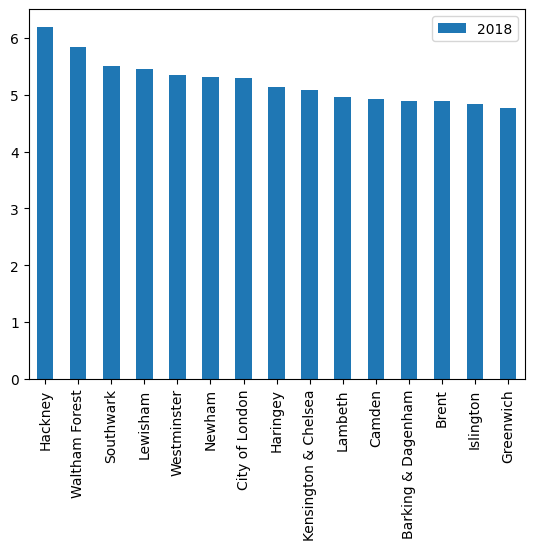

In [102]:
# Plot the top 15 boroughs with the highest price ratios.
ax = top15[['Borough', '2018']].plot(kind='bar')

ax.set_xticklabels(top15.Borough)

## **4. Conclusion**

### Based on the 2018 bar chart, Hackney had the highest value at around 6.2, followed by Waltham Forest, Southwark, Lewisham, and Westminster. In contrast, Greenwich recorded the lowest value at approximately 4.8, while Islington, Brent, and Barking & Dagenham were also among the lower-ranked boroughs. Although there are some differences in the values, most boroughs fall within a similar range of 4.8 to 5.5. This suggests that the overall performance across the boroughs was fairly consistent, with Hackney showing the highest value and Greenwich the lowest in 2018.